In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!nvidia-smi

Mon May 18 09:45:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   28C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -q segmentation-models-pytorch albumentations opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.5 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import os
import shutil
import random
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

ALPHADENT_DATASET = BASE_DIR / "data_prepared" / "alphadent_yolo_seg_2class"

DEEPLAB_DATASET = BASE_DIR / "data_prepared" / "alphadent_deeplab_semantic"
DEEPLAB_IMAGES = DEEPLAB_DATASET / "images"
DEEPLAB_MASKS = DEEPLAB_DATASET / "masks"

RUNS_DIR = BASE_DIR / "runs" / "alphadent_deeplab"
RESULTS_DIR = BASE_DIR / "results" / "alphadent_deeplab"
FINAL_MODELS_DIR = BASE_DIR / "final_models" / "alphadent_deeplab"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("AlphaDent YOLO-seg dataset:", ALPHADENT_DATASET)
print("DeepLab dataset:", DEEPLAB_DATASET)
print("AlphaDent var mı?:", ALPHADENT_DATASET.exists())

AlphaDent YOLO-seg dataset: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_yolo_seg_2class
DeepLab dataset: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_deeplab_semantic
AlphaDent var mı?: True


In [5]:
for split in ["train", "val"]:
    img_dir = ALPHADENT_DATASET / "images" / split
    label_dir = ALPHADENT_DATASET / "labels" / split

    img_count = len(list(img_dir.glob("*.jpg")))
    label_count = len(list(label_dir.glob("*.txt")))

    print(split)
    print("images:", img_count)
    print("labels:", label_count)
    print("-" * 50)

train
images: 1208
labels: 1208
--------------------------------------------------
val
images: 82
labels: 82
--------------------------------------------------


In [6]:
def yolo_seg_to_mask(img_path, label_path, mask_path):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    mask = np.zeros((h, w), dtype=np.uint8)

    if label_path.exists():
        text = label_path.read_text(errors="ignore").strip()

        if text != "":
            lines = text.splitlines()

            for line in lines:
                line = line.strip()

                if line == "":
                    continue

                parts = line.split()

                if len(parts) < 7:
                    continue

                cls_id = int(float(parts[0]))
                coords = list(map(float, parts[1:]))

                xs = coords[0::2]
                ys = coords[1::2]

                pts = []

                for x, y in zip(xs, ys):
                    px = int(round(x * w))
                    py = int(round(y * h))

                    px = max(0, min(w - 1, px))
                    py = max(0, min(h - 1, py))

                    pts.append([px, py])

                if len(pts) >= 3:
                    pts_np = np.array([pts], dtype=np.int32)

                    # 0 background, 1 dis_asinmasi, 2 dis_curugu
                    mask_value = cls_id + 1

                    cv2.fillPoly(mask, pts_np, mask_value)

    cv2.imwrite(str(mask_path), mask)

In [7]:
if DEEPLAB_DATASET.exists():
    shutil.rmtree(DEEPLAB_DATASET)

for split in ["train", "val"]:
    (DEEPLAB_IMAGES / split).mkdir(parents=True, exist_ok=True)
    (DEEPLAB_MASKS / split).mkdir(parents=True, exist_ok=True)

for split in ["train", "val"]:
    img_dir = ALPHADENT_DATASET / "images" / split
    label_dir = ALPHADENT_DATASET / "labels" / split

    img_paths = sorted(list(img_dir.glob("*.jpg")))

    for img_path in tqdm(img_paths, desc=f"{split} mask üretiliyor"):
        label_path = label_dir / f"{img_path.stem}.txt"

        dst_img = DEEPLAB_IMAGES / split / img_path.name
        dst_mask = DEEPLAB_MASKS / split / f"{img_path.stem}.png"

        shutil.copy2(img_path, dst_img)
        yolo_seg_to_mask(img_path, label_path, dst_mask)

print("DeepLab semantic dataset hazır:")
print(DEEPLAB_DATASET)

train mask üretiliyor:   0%|          | 0/1208 [00:00<?, ?it/s]

val mask üretiliyor:   0%|          | 0/82 [00:00<?, ?it/s]

DeepLab semantic dataset hazır:
/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/alphadent_deeplab_semantic


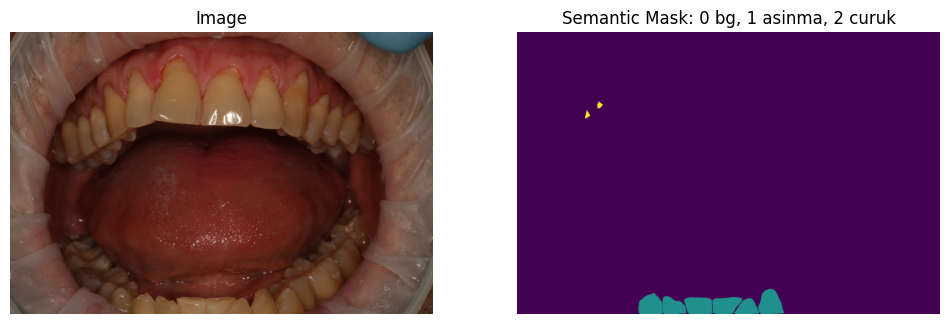

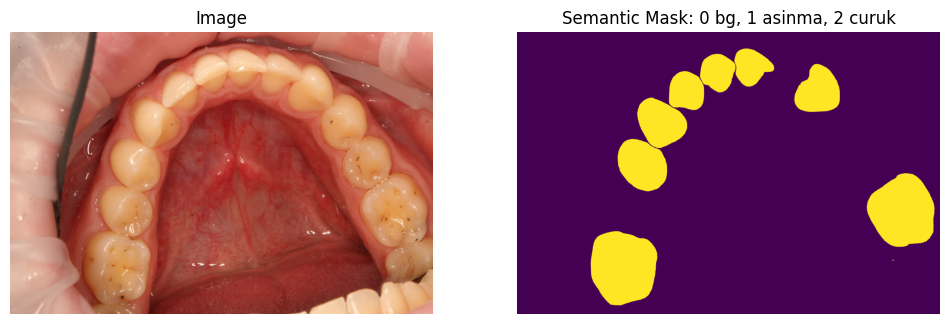

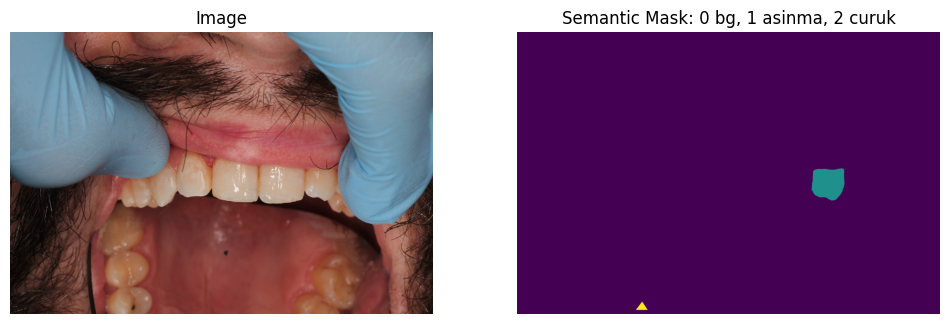

In [8]:
sample_mask_paths = list((DEEPLAB_MASKS / "train").glob("*.png"))

for mask_path in random.sample(sample_mask_paths, min(3, len(sample_mask_paths))):
    img_path = DEEPLAB_IMAGES / "train" / f"{mask_path.stem}.jpg"

    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.axis("off")
    plt.title("Semantic Mask: 0 bg, 1 asinma, 2 curuk")

    plt.show()

In [9]:
mask_counter = {
    0: 0,
    1: 0,
    2: 0
}

for split in ["train", "val"]:
    mask_paths = list((DEEPLAB_MASKS / split).glob("*.png"))

    for mask_path in tqdm(mask_paths, desc=f"{split} mask sınıf sayımı"):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        values, counts = np.unique(mask, return_counts=True)

        for v, c in zip(values, counts):
            if int(v) in mask_counter:
                mask_counter[int(v)] += int(c)

df_mask_pixel_counts = pd.DataFrame([
    {
        "mask_value": k,
        "class_name": {
            0: "background",
            1: "dis_asinmasi",
            2: "dis_curugu"
        }[k],
        "pixel_count": v
    }
    for k, v in mask_counter.items()
])

df_mask_pixel_counts

train mask sınıf sayımı:   0%|          | 0/1208 [00:00<?, ?it/s]

val mask sınıf sayımı:   0%|          | 0/82 [00:00<?, ?it/s]

,mask_value,class_name,pixel_count
0,0,background,22968014110
1,1,dis_asinmasi,1121824995
2,2,dis_curugu,109054463


In [10]:
class AlphaDentSemanticDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.image_paths = sorted(list(self.image_dir.glob("*.jpg")))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_dir / f"{img_path.stem}.png"

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].long()

        return image, mask

In [11]:
DEEPLAB_IMGSZ = 512
DEEPLAB_BATCH = 4

train_transform = A.Compose([
    A.Resize(DEEPLAB_IMGSZ, DEEPLAB_IMGSZ),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(DEEPLAB_IMGSZ, DEEPLAB_IMGSZ),
    A.Normalize(),
    ToTensorV2()
])

train_dataset = AlphaDentSemanticDataset(
    DEEPLAB_IMAGES / "train",
    DEEPLAB_MASKS / "train",
    transform=train_transform
)

val_dataset = AlphaDentSemanticDataset(
    DEEPLAB_IMAGES / "val",
    DEEPLAB_MASKS / "val",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=DEEPLAB_BATCH,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DEEPLAB_BATCH,
    shuffle=False,
    num_workers=0
)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Batch:", DEEPLAB_BATCH)
print("Image size:", DEEPLAB_IMGSZ)

Train dataset: 1208
Val dataset: 82
Batch: 4
Image size: 512


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3
)

deeplab_model = deeplab_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(deeplab_model.parameters(), lr=1e-4, weight_decay=1e-4)

print("Device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Device: cuda


In [13]:
def compute_mean_iou(outputs, masks, num_classes=3):
    preds = torch.argmax(outputs, dim=1)

    ious = []

    for cls in range(1, num_classes):  # background hariç
        pred_cls = preds == cls
        mask_cls = masks == cls

        intersection = (pred_cls & mask_cls).sum().float()
        union = (pred_cls | mask_cls).sum().float()

        if union == 0:
            continue

        iou = intersection / union
        ious.append(iou.item())

    if len(ious) == 0:
        return 0.0

    return sum(ious) / len(ious)

In [14]:
DEEPLAB_RUN_NAME = "deeplabv3plus_resnet34_512_30ep"
DEEPLAB_RUN_DIR = RUNS_DIR / DEEPLAB_RUN_NAME
DEEPLAB_RUN_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = DEEPLAB_RUN_DIR / "checkpoint_last.pth"
BEST_MODEL_PATH = DEEPLAB_RUN_DIR / "best_model.pth"
HISTORY_CSV = DEEPLAB_RUN_DIR / "history.csv"

print("Run dir:", DEEPLAB_RUN_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Best model:", BEST_MODEL_PATH)
print("History:", HISTORY_CSV)

Run dir: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent_deeplab/deeplabv3plus_resnet34_512_30ep
Checkpoint: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent_deeplab/deeplabv3plus_resnet34_512_30ep/checkpoint_last.pth
Best model: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent_deeplab/deeplabv3plus_resnet34_512_30ep/best_model.pth
History: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent_deeplab/deeplabv3plus_resnet34_512_30ep/history.csv


In [15]:
start_epoch = 0
best_val_miou = 0.0
deeplab_history = []

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    deeplab_model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_miou = checkpoint.get("best_val_miou", 0.0)
    deeplab_history = checkpoint.get("history", [])

    print("Checkpoint yüklendi.")
    print("Devam edilecek epoch:", start_epoch + 1)
    print("Best val mIoU:", best_val_miou)
else:
    print("Checkpoint bulunamadı. Eğitim sıfırdan başlayacak.")

Checkpoint bulunamadı. Eğitim sıfırdan başlayacak.


In [16]:
DEEPLAB_EPOCHS = 30

for epoch in range(start_epoch, DEEPLAB_EPOCHS):
    deeplab_model.train()

    train_loss = 0.0
    train_iou = 0.0

    for images_batch, masks_batch in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{DEEPLAB_EPOCHS} train"
    ):
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        optimizer.zero_grad()

        outputs = deeplab_model(images_batch)
        loss = criterion(outputs, masks_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_iou += compute_mean_iou(outputs.detach(), masks_batch.detach())

    train_loss /= len(train_loader)
    train_iou /= len(train_loader)

    deeplab_model.eval()

    val_loss = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for images_batch, masks_batch in tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{DEEPLAB_EPOCHS} val"
        ):
            images_batch = images_batch.to(device)
            masks_batch = masks_batch.to(device)

            outputs = deeplab_model(images_batch)
            loss = criterion(outputs, masks_batch)

            val_loss += loss.item()
            val_iou += compute_mean_iou(outputs, masks_batch)

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_mIoU": train_iou,
        "val_loss": val_loss,
        "val_mIoU": val_iou
    }

    deeplab_history.append(row)

    print(row)

    # Her epoch sonunda checkpoint kaydet
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": deeplab_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_miou": best_val_miou,
        "history": deeplab_history
    }

    torch.save(checkpoint, CHECKPOINT_PATH)

    # En iyi modeli ayrıca kaydet
    if val_iou > best_val_miou:
        best_val_miou = val_iou
        checkpoint["best_val_miou"] = best_val_miou
        torch.save(checkpoint, BEST_MODEL_PATH)
        print("Yeni en iyi model kaydedildi:", BEST_MODEL_PATH)

    # History CSV kaydet
    df_deeplab_history = pd.DataFrame(deeplab_history)
    df_deeplab_history.to_csv(HISTORY_CSV, index=False)

print("DeepLabV3+ eğitimi tamamlandı.")

Epoch 1/30 train:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 1/30 val:   0%|          | 0/21 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.294939015208688, 'train_mIoU': 0.14886084048142442, 'val_loss': 0.14524024299212865, 'val_mIoU': 0.21257940147604262}
Yeni en iyi model kaydedildi: /content/drive/MyDrive/DIS_PROJESI_007/runs/alphadent_deeplab/deeplabv3plus_resnet34_512_30ep/best_model.pth


Epoch 2/30 train:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 2/30 val:   0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch 29/30 val:   0%|          | 0/21 [00:00<?, ?it/s]

{'epoch': 29, 'train_loss': 0.018517746418924227, 'train_mIoU': 0.6788715321475421, 'val_loss': 0.14162484290344374, 'val_mIoU': 0.3357823907087247}


Epoch 30/30 train:   0%|          | 0/302 [00:00<?, ?it/s]

Epoch 30/30 val:   0%|          | 0/21 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 0.018488713694329292, 'train_mIoU': 0.6817411115356037, 'val_loss': 0.15622038873178618, 'val_mIoU': 0.3411643945922454}
DeepLabV3+ eğitimi tamamlandı.


In [17]:
df_deeplab_history = pd.read_csv(HISTORY_CSV)

df_deeplab_history.tail()

,epoch,train_loss,train_mIoU,val_loss,val_mIoU
25,26,0.021976,0.651645,0.136417,0.348589
26,27,0.021881,0.652249,0.136768,0.364279
27,28,0.021181,0.658031,0.134233,0.337130
28,29,0.018518,0.678872,0.141625,0.335782
29,30,0.018489,0.681741,0.156220,0.341164


In [18]:
best_epoch_row = df_deeplab_history.loc[df_deeplab_history["val_mIoU"].idxmax()]

df_deeplab_summary = pd.DataFrame([{
    "model": "DeepLabV3+ ResNet34",
    "task": "semantic_segmentation",
    "imgsz": DEEPLAB_IMGSZ,
    "epochs": DEEPLAB_EPOCHS,
    "batch": DEEPLAB_BATCH,
    "best_epoch": int(best_epoch_row["epoch"]),
    "best_val_mIoU": float(best_epoch_row["val_mIoU"]),
    "best_model_path": str(BEST_MODEL_PATH),
    "history_csv": str(HISTORY_CSV)
}])

df_deeplab_summary

,model,task,imgsz,epochs,batch,best_epoch,best_val_mIoU,best_model_path,history_csv
0,DeepLabV3+ ResNet34,semantic_segmentation,512,30,4,16,0.37288,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...,/content/drive/MyDrive/DIS_PROJESI_007/runs/al...


In [19]:
deeplab_summary_csv = RESULTS_DIR / "deeplabv3plus_resnet34_512_30ep_summary.csv"

df_deeplab_summary.to_csv(deeplab_summary_csv, index=False)

print("Kaydedildi:")
print(deeplab_summary_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_deeplab/deeplabv3plus_resnet34_512_30ep_summary.csv


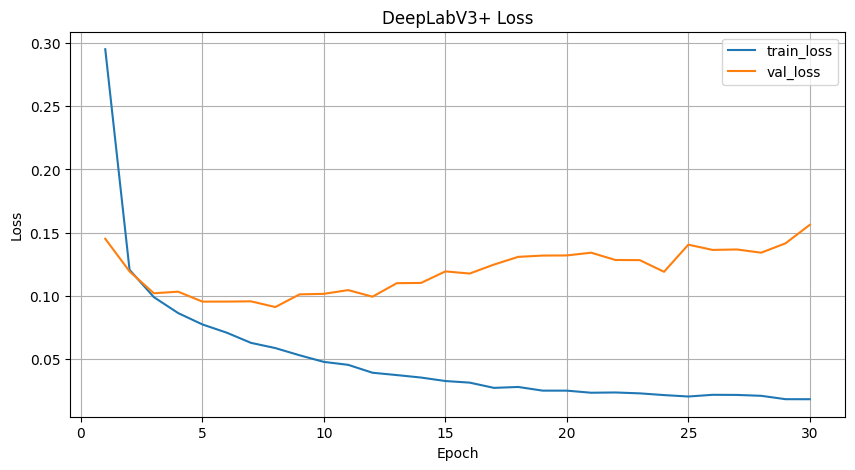

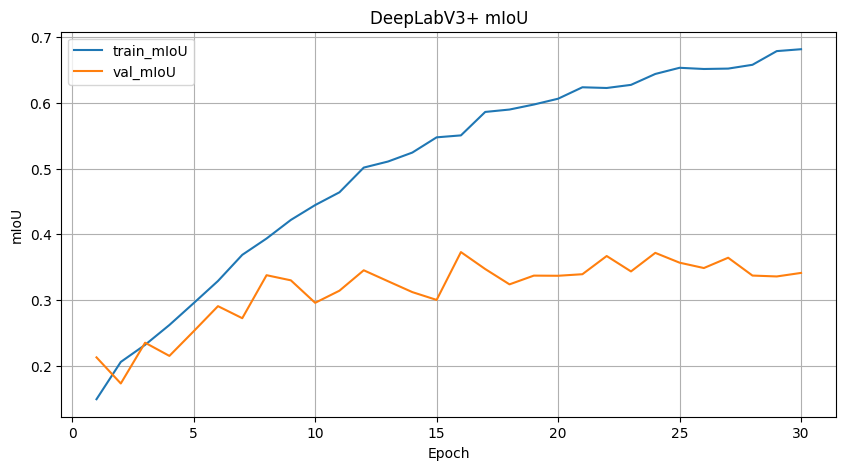

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(df_deeplab_history["epoch"], df_deeplab_history["train_loss"], label="train_loss")
plt.plot(df_deeplab_history["epoch"], df_deeplab_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DeepLabV3+ Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_deeplab_history["epoch"], df_deeplab_history["train_mIoU"], label="train_mIoU")
plt.plot(df_deeplab_history["epoch"], df_deeplab_history["val_mIoU"], label="val_mIoU")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title("DeepLabV3+ mIoU")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
best_checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

deeplab_model.load_state_dict(best_checkpoint["model_state_dict"])
deeplab_model.eval()

print("En iyi DeepLab modeli yüklendi.")
print("Best val mIoU:", best_checkpoint["best_val_miou"])

En iyi DeepLab modeli yüklendi.
Best val mIoU: 0.37288005139479147


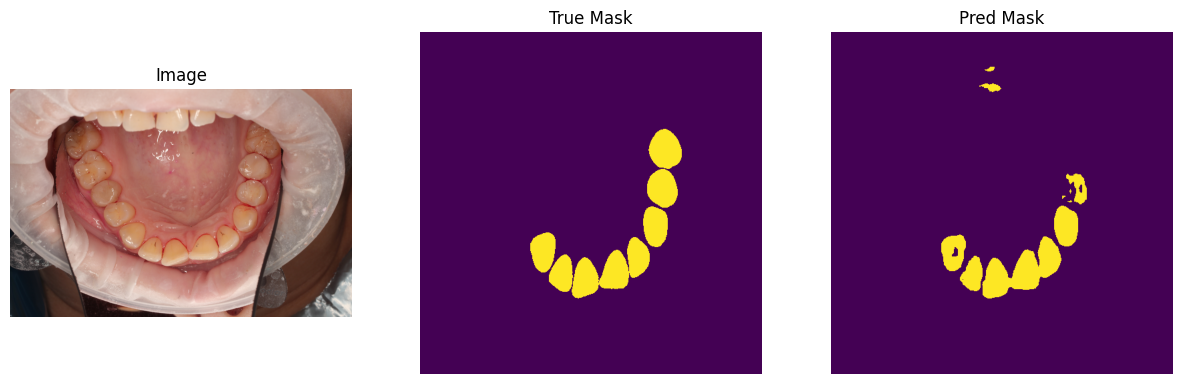

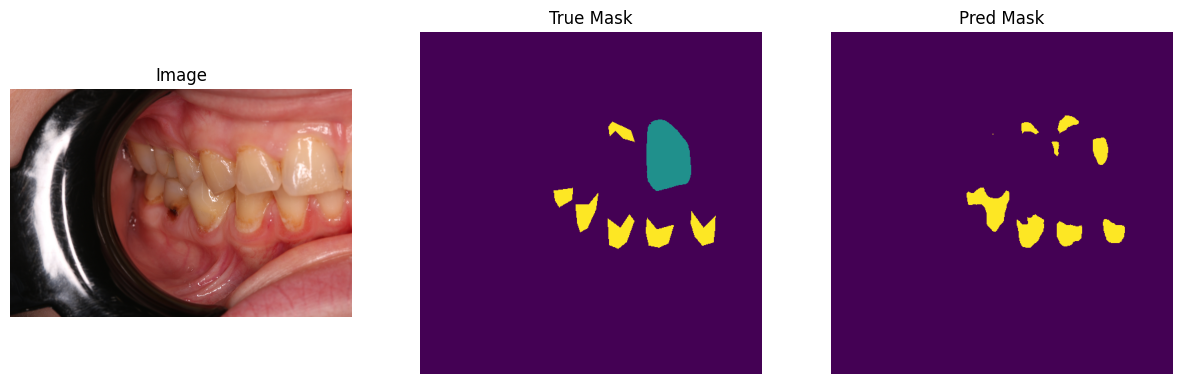

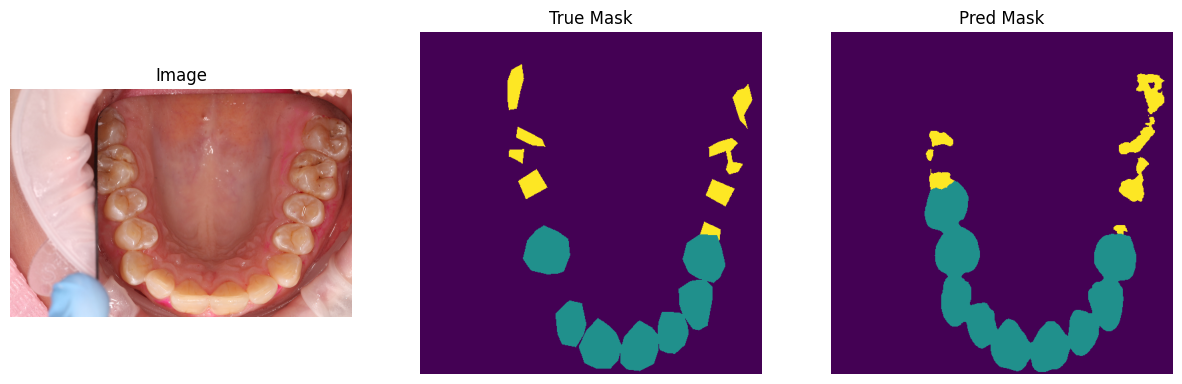

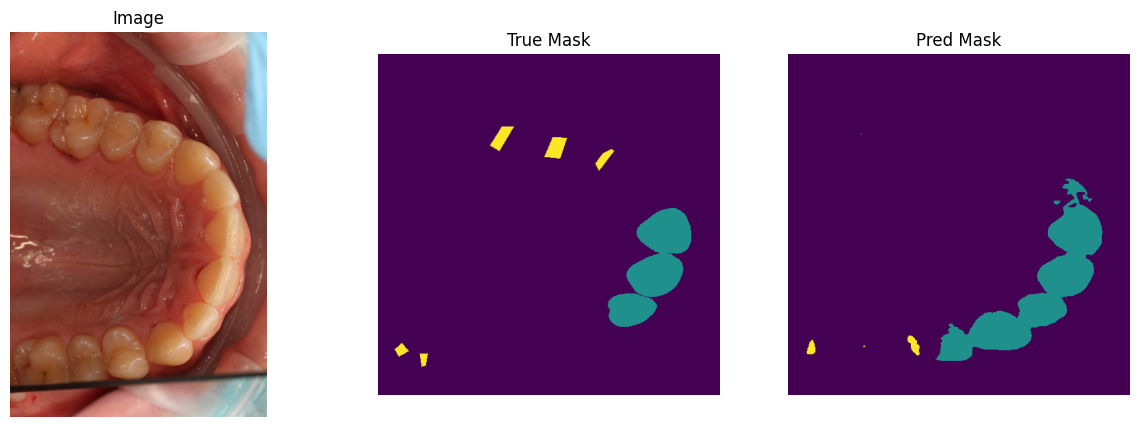

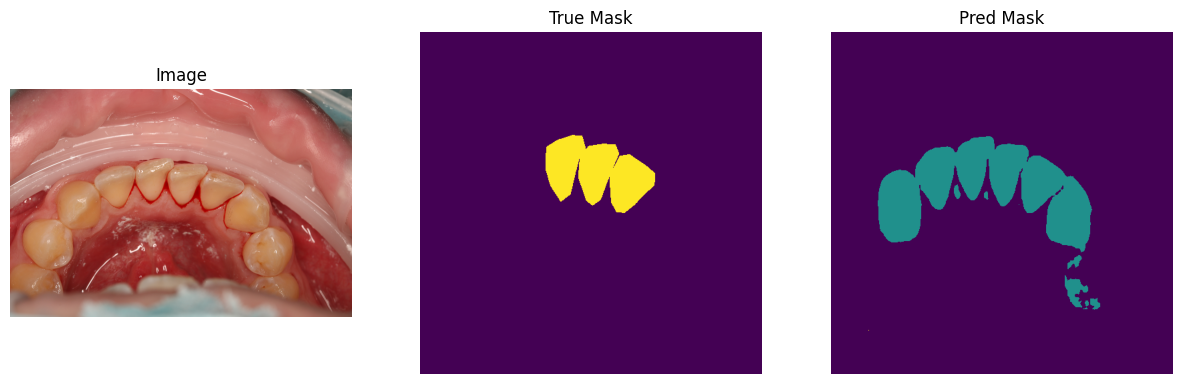

In [22]:
val_sample_indices = random.sample(range(len(val_dataset)), min(5, len(val_dataset)))

with torch.no_grad():
    for idx in val_sample_indices:
        image_tensor, mask_tensor = val_dataset[idx]

        input_tensor = image_tensor.unsqueeze(0).to(device)

        output = deeplab_model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        true_mask = mask_tensor.cpu().numpy()

        img_path = val_dataset.image_paths[idx]
        raw_img = Image.open(img_path).convert("RGB")

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(raw_img)
        plt.axis("off")
        plt.title("Image")

        plt.subplot(1, 3, 2)
        plt.imshow(true_mask)
        plt.axis("off")
        plt.title("True Mask")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask)
        plt.axis("off")
        plt.title("Pred Mask")

        plt.show()

In [23]:
final_deeplab_path = FINAL_MODELS_DIR / "alphadent_deeplabv3plus_resnet34_512_30ep_best.pth"

shutil.copy2(BEST_MODEL_PATH, final_deeplab_path)

print("DeepLab final model kaydedildi:")
print(final_deeplab_path)

DeepLab final model kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/final_models/alphadent_deeplab/alphadent_deeplabv3plus_resnet34_512_30ep_best.pth


In [24]:
yolo_seg_best_csv = BASE_DIR / "results" / "alphadent_training" / "alphadent_all_seg_models_with_final_comparison.csv"

if yolo_seg_best_csv.exists():
    df_yolo_seg = pd.read_csv(yolo_seg_best_csv)
    yolo_best = df_yolo_seg.sort_values("mask_mAP50", ascending=False).iloc[0]

    yolo_row = {
        "model": yolo_best["model"],
        "run_name": yolo_best["run_name"],
        "task": "instance_segmentation",
        "metric_type": "mask_mAP",
        "main_metric_name": "mask_mAP50",
        "main_metric_value": float(yolo_best["mask_mAP50"]),
        "secondary_metric_name": "mask_mAP50-95",
        "secondary_metric_value": float(yolo_best["mask_mAP50-95"])
    }
else:
    yolo_row = {
        "model": "YOLOv8m-seg",
        "run_name": "yolov8m_seg_640_30ep_or_final",
        "task": "instance_segmentation",
        "metric_type": "mask_mAP",
        "main_metric_name": "mask_mAP50",
        "main_metric_value": None,
        "secondary_metric_name": "mask_mAP50-95",
        "secondary_metric_value": None
    }

deeplab_row = {
    "model": "DeepLabV3+ ResNet34",
    "run_name": DEEPLAB_RUN_NAME,
    "task": "semantic_segmentation",
    "metric_type": "mIoU",
    "main_metric_name": "val_mIoU",
    "main_metric_value": float(df_deeplab_summary.iloc[0]["best_val_mIoU"]),
    "secondary_metric_name": "best_epoch",
    "secondary_metric_value": int(df_deeplab_summary.iloc[0]["best_epoch"])
}

df_segmentation_method_comparison = pd.DataFrame([
    yolo_row,
    deeplab_row
])

df_segmentation_method_comparison

,model,run_name,task,metric_type,main_metric_name,main_metric_value,secondary_metric_name,secondary_metric_value
0,YOLOv8m-seg,yolov8m_seg_640_30ep,instance_segmentation,mask_mAP,mask_mAP50,0.612124,mask_mAP50-95,0.411457
1,DeepLabV3+ ResNet34,deeplabv3plus_resnet34_512_30ep,semantic_segmentation,mIoU,val_mIoU,0.372880,best_epoch,16.000000


In [25]:
method_compare_csv = RESULTS_DIR / "alphadent_yoloseg_vs_deeplabv3plus_method_comparison.csv"

df_segmentation_method_comparison.to_csv(method_compare_csv, index=False)

print("Kaydedildi:")
print(method_compare_csv)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_deeplab/alphadent_yoloseg_vs_deeplabv3plus_method_comparison.csv


In [26]:
comment = f"""
DeepLabV3+ modeli AlphaDent veri seti üzerinde semantic segmentation yaklaşımıyla denenmiştir.
YOLO-seg modellerinden farklı olarak DeepLabV3+ instance segmentation değil, piksel tabanlı semantic segmentation
üretmektedir. Bu nedenle YOLO-seg sonuçları mask mAP metrikleriyle, DeepLabV3+ sonucu ise mIoU metriğiyle
değerlendirilmiştir.

DeepLabV3+ ResNet34 modeli {DEEPLAB_EPOCHS} epoch eğitim sonucunda en iyi val_mIoU={df_deeplab_summary.iloc[0]['best_val_mIoU']:.4f}
değerine ulaşmıştır. Bu sonuç, literatürde yaygın kullanılan semantic segmentation mimarisinin proje kapsamında
ek bir karşılaştırma modeli olarak değerlendirilebilmesini sağlamıştır.
"""

print(comment)


DeepLabV3+ modeli AlphaDent veri seti üzerinde semantic segmentation yaklaşımıyla denenmiştir.
YOLO-seg modellerinden farklı olarak DeepLabV3+ instance segmentation değil, piksel tabanlı semantic segmentation
üretmektedir. Bu nedenle YOLO-seg sonuçları mask mAP metrikleriyle, DeepLabV3+ sonucu ise mIoU metriğiyle
değerlendirilmiştir.

DeepLabV3+ ResNet34 modeli 30 epoch eğitim sonucunda en iyi val_mIoU=0.3729
değerine ulaşmıştır. Bu sonuç, literatürde yaygın kullanılan semantic segmentation mimarisinin proje kapsamında
ek bir karşılaştırma modeli olarak değerlendirilebilmesini sağlamıştır.



In [27]:
comment_path = RESULTS_DIR / "deeplabv3plus_alphadent_comment.txt"

comment_path.write_text(comment, encoding="utf-8")

print("Yorum kaydedildi:")
print(comment_path)

Yorum kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/alphadent_deeplab/deeplabv3plus_alphadent_comment.txt
